# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


# Student Answers

For This lab, we will explore the **UCI Heart Disease dataset (Cleveland Clinic subset)**.  
Our goal is to understand the dataset, visualize feature relationships, and identify which features are most predictive of **heart disease**.

- **Dataset size**: 303 patients  
- **Target feature**: `target`  
  - `0` → No heart disease  
  - `1` → Heart disease present  

We will analyze 5 features:  
- `age` years
- `sex` (1 = male, 0 = female)  
- `cp` scale 0–3 
- `chol` (serum cholesterol mg/dl)  
- `thalach` (maximum heart rate achieved)  
- `trestbps` (resting blood pressure)  


# Processsing the data 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
col_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]
df = pd.read_csv("processed.cleveland.csv", names=col_names)

# Convert to numeric
df = df.apply(pd.to_numeric, errors="coerce")

# Simplify target: 0 = no disease, 1 = disease present
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## Distribution of Target Feature

This shows how many patients had heart disease vs. no heart disease.


C:\Users\kilgo\AppData\Local\Temp\ipykernel_39804\1196905532.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette="Set2")


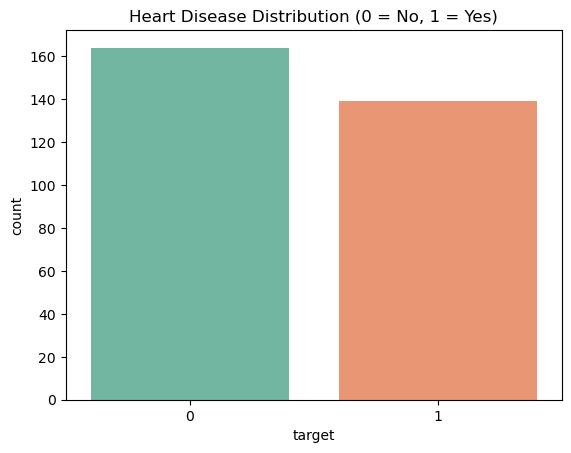

In [4]:
sns.countplot(x="target", data=df, palette="Set2")
plt.title("Heart Disease Distribution (0 = No, 1 = Yes)")
plt.show()


## Age vs Heart Disease

We check whether age influences the likelihood of heart disease.


plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="age", data=df, palette="Set3")
plt.title("Age Distribution by Heart Disease")
plt.show()


**Interpretation**:  
Patients with heart disease are often older, but younger individuals can also be affected.


## Sex vs Heart Disease

We analyze whether males or females are more likely to have heart disease.


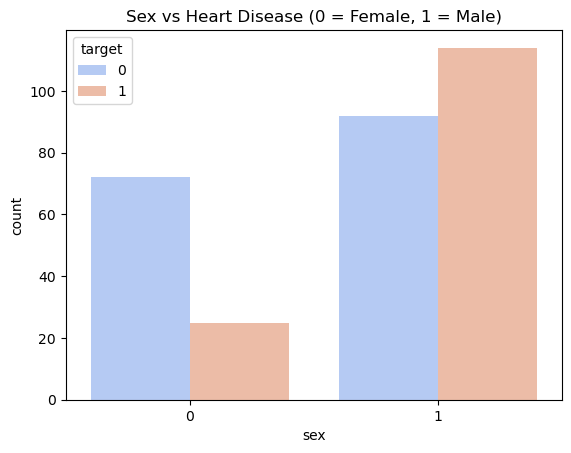

In [8]:
sns.countplot(x="sex", hue="target", data=df, palette="coolwarm")
plt.title("Sex vs Heart Disease (0 = Female, 1 = Male)")
plt.show()


**Interpretation**:  
Males are more likely to have heart disease than females in this dataset

Target 0 = no heart disease 1 = yes heart disease

## Chest Pain Type vs Heart Disease

Chest pain type (`cp`) ranges from:  
- 0 = typical angina  
- 1 = atypical angina  
- 2 = non-anginal pain  
- 3 = asymptomatic


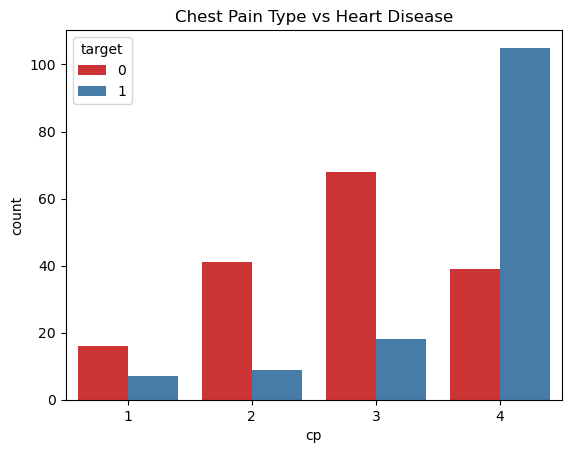

In [9]:
sns.countplot(x="cp", hue="target", data=df, palette="Set1")
plt.title("Chest Pain Type vs Heart Disease")
plt.show()


**Interpretation**:  
Asymptomatic chest pain (`cp=4`) is strongly linked with heart disease.
Red is no heart disease Blue is heart disease


## Cholesterol vs Heart Disease


C:\Users\kilgo\AppData\Local\Temp\ipykernel_39804\3437250412.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="chol", data=df, palette="muted")


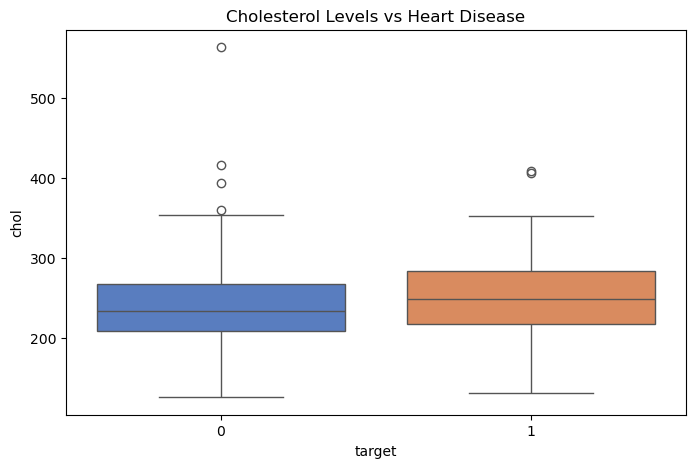

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="chol", data=df, palette="muted")
plt.title("Cholesterol Levels vs Heart Disease")
plt.show()


**Interpretation**:  
Cholesterol shows some variation but is not the strongest predictor of heart disease.


## Maximum Heart Rate (Thalach) vs Heart Disease


C:\Users\kilgo\AppData\Local\Temp\ipykernel_39804\2803968499.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="thalach", data=df, palette="Set2")


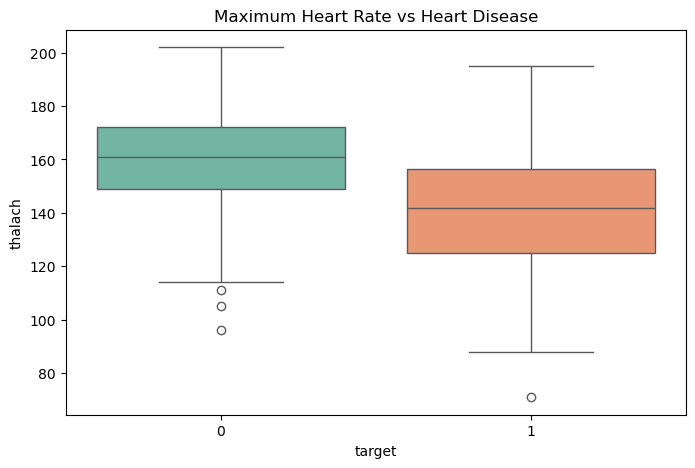

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="thalach", data=df, palette="Set2")
plt.title("Maximum Heart Rate vs Heart Disease")
plt.show()


**Interpretation**:  
Patients without heart disease tend to reach higher maximum heart rates.


## Correlation Heatmap

This shows relationships between numeric features and the target.


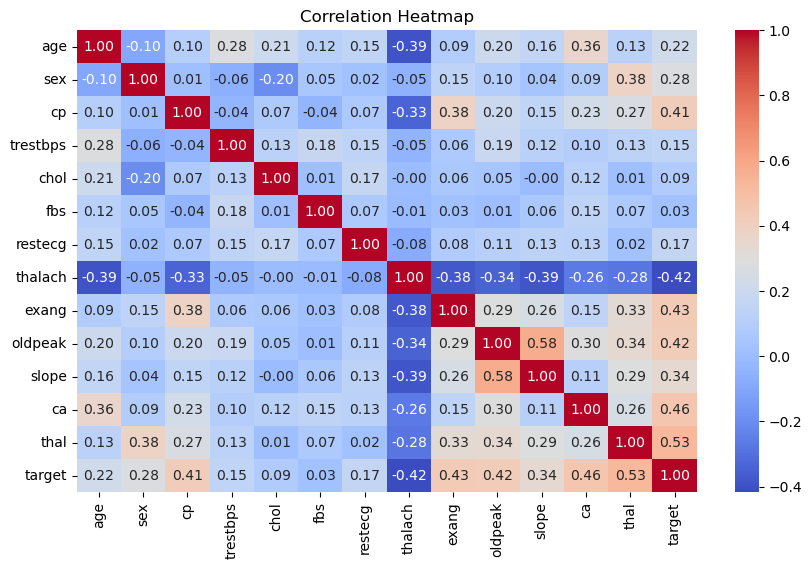

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


# Conclusion

From our dataset, we found that:

- **Sex**: Older males are more likely to develop heart disease.  
- **Chest Pain Type**: Asymptomatic chest pain is a strong indicator of disease.  
- **Maximum Heart Rate (thalach)**: Higher heart rates are protective.  
- **Age**: Older patients are more at risk.  
- **Cholesterol**: Shows weaker correlation than expected.  

The most important predictors of heart disease in this dataset are:  
**Chest Pain Type, Sex, Age, and Maximum Heart Rate.**
